In [1]:
import geopandas as gpd
import rasterio
import numpy as np
import rasterio.mask
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import pandas as pd
from shapely import wkt
import seaborn as sns


/Users/ruthparajo/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [ ]:
def promedio_rgb_por_celda(ruta_raster, grid):
    r_means, g_means, b_means = [], [], []
    with rasterio.open(ruta_raster) as src:
        for geom in grid.geometry:
            try:
                # Extraer solo el área de la geometría
                out_image, _ = rasterio.mask.mask(src, [geom], crop=True)
                
                # Separar las bandas RGB
                r, g, b = out_image[0].astype(float), out_image[1].astype(float), out_image[2].astype(float)

                nodata = src.nodata
                if nodata is not None:
                    r[r == nodata] = np.nan
                    g[g == nodata] = np.nan
                    b[b == nodata] = np.nan

                # Calcular promedios
                r_means.append(np.nanmean(r))
                g_means.append(np.nanmean(g))
                b_means.append(np.nanmean(b))

            except Exception:
                r_means.append(np.nan)
                g_means.append(np.nan)
                b_means.append(np.nan)

    grid["mean_r"] = r_means
    grid["mean_g"] = g_means
    grid["mean_b"] = b_means
    return grid

In [25]:
df = pd.read_csv('datos/grid_data_2001_2013.csv')
df['geometry'] = df['geometry'].apply(wkt.loads)

In [26]:
df = gpd.GeoDataFrame(df, geometry='geometry')
df['x'] = df.geometry.centroid.x
df['y'] = df.geometry.centroid.y

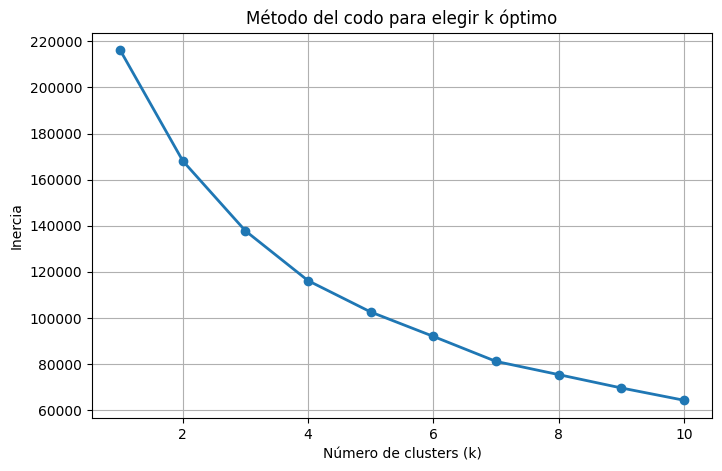

In [4]:

def metodo_del_codo(gdf, columnas_variables, max_clusters=10):
    """
    Aplica el método del codo para encontrar el número óptimo de clusters.
    
    Parámetros:
    - gdf: GeoDataFrame con tus datos
    - columnas_variables: lista de columnas a usar para clustering (deben ser numéricas)
    - max_clusters: número máximo de clusters a evaluar
    
    Retorna:
    - Lista de inercias para cada k
    """
    
    # Preparar los datos
    X = gdf[columnas_variables].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)


    inercias = []
    K_range = range(1, max_clusters + 1)

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X_scaled)
        inercias.append(kmeans.inertia_)

    # Graficar el codo
    plt.figure(figsize=(8, 5))
    plt.plot(K_range, inercias, 'o-', linewidth=2)
    plt.xlabel('Número de clusters (k)')
    plt.ylabel('Inercia')
    plt.title('Método del codo para elegir k óptimo')
    plt.grid(True)
    plt.show()

    return inercias
variables = ['ndvi', 'lst', 'presencia_lobos','nlcd', 'x', 'y']  # Asegúrate de tener 'x', 'y' en el GeoDataFrame
inercias = metodo_del_codo(df, columnas_variables=variables, max_clusters=10)


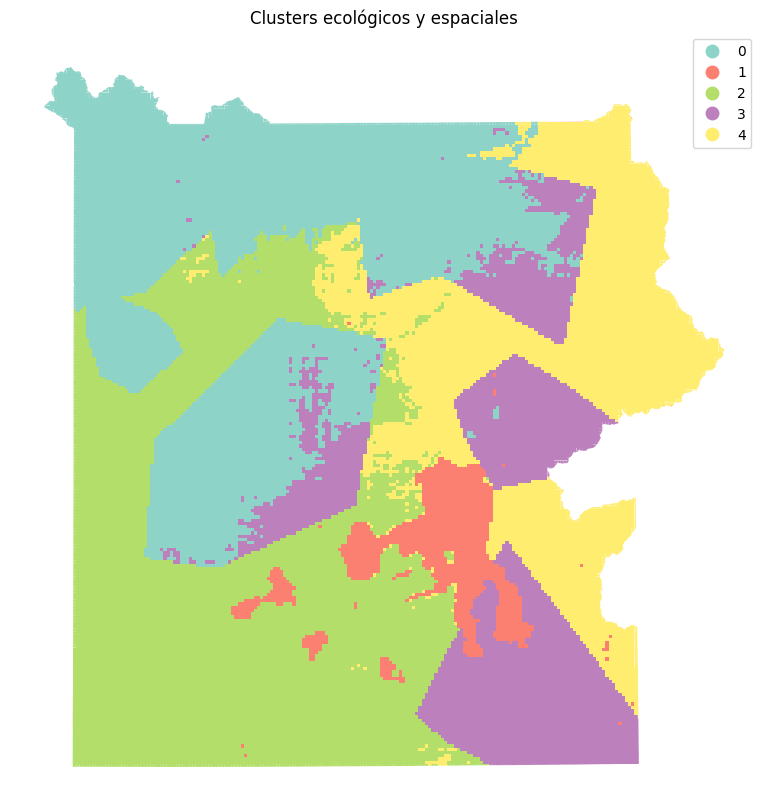

In [27]:
X = df[variables].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)


fig, ax = plt.subplots(figsize=(10, 10))

df.plot(column='cluster', ax=ax, categorical=True, legend=True, cmap='Set3', markersize=2)

ax.set_title('Clusters ecológicos y espaciales')
ax.axis('off')
plt.show()


/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/835093519.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=var, data=df, palette="pastel")
/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/835093519.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=var, data=df, palette="pastel")


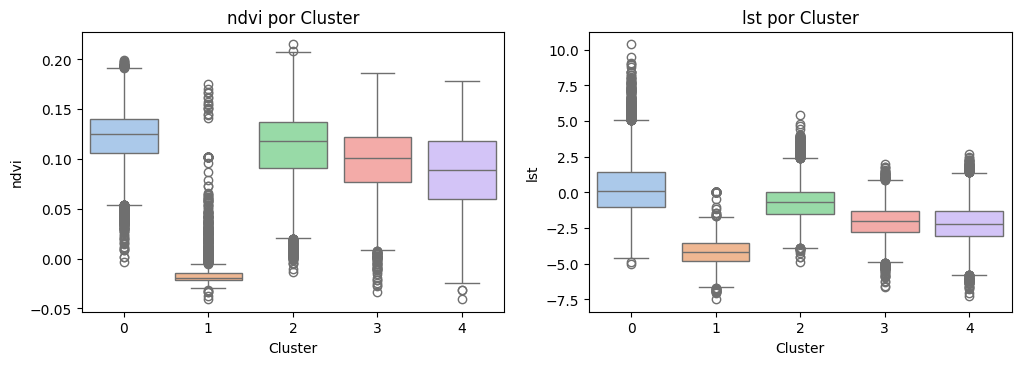

In [28]:
features_box = ['ndvi', 'lst']
n_cols = 2
n_rows = (len(features_box) + 1 + n_cols - 1) // n_cols  

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, var in enumerate(features_box):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x="cluster", y=var, data=df, palette="pastel")
    plt.title(f"{var} por Cluster")
    plt.xlabel("Cluster")
    plt.ylabel(var)


/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/3721890176.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="cluster", y="presencia_lobos", data=lobos_por_cluster, palette="muted")


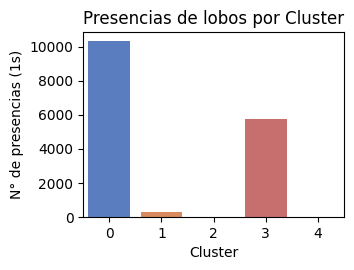

In [29]:

plt.subplot(n_rows, n_cols, len(features_box) + 1)


lobos_por_cluster = df.groupby('cluster')['presencia_lobos'].sum().reset_index()
sns.barplot(x="cluster", y="presencia_lobos", data=lobos_por_cluster, palette="muted")

plt.title("Presencias de lobos por Cluster")
plt.xlabel("Cluster")
plt.ylabel("N° de presencias (1s)")

plt.tight_layout()
plt.show()

/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/4036421521.py:20: RuntimeWarning: Mean of empty slice
  r_means.append(np.nanmean(r))
/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/4036421521.py:21: RuntimeWarning: Mean of empty slice
  g_means.append(np.nanmean(g))
/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/4036421521.py:22: RuntimeWarning: Mean of empty slice
  b_means.append(np.nanmean(b))
/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/4036421521.py:20: RuntimeWarning: Mean of empty slice
  r_means.append(np.nanmean(r))
/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/4036421521.py:21: RuntimeWarning: Mean of empty slice
  g_means.append(np.nanmean(g))
/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/4036421521.py:22: RuntimeWarning: Mean of empty slice
  b_means.append(np.nanmean(b))
/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/4036421521.py:20: RuntimeWarn

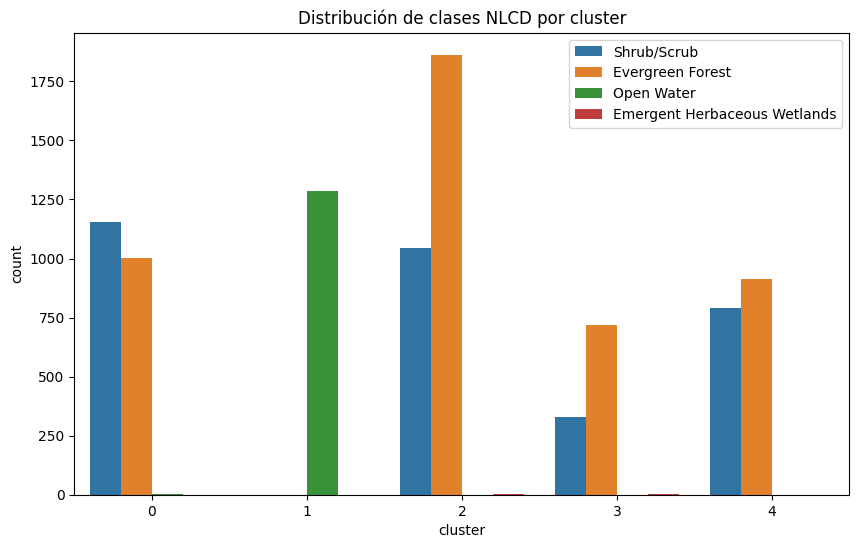

In [30]:
df2 = df.copy()
promedio_rgb_por_celda("datos/NLCD_reprojected_2021.tif", df2)
df2['mean_r'] = df2['mean_r'].fillna(df2['mean_r'].mean())
df2['mean_g'] = df2['mean_g'].fillna(df2['mean_g'].mean())
df2['mean_b'] = df2['mean_b'].fillna(df2['mean_b'].mean())
nlcd_labels = [
    "Open Water", "Developed, Open Space", "Developed, Low Intensity", 
    "Developed, Medium Intensity", "Developed, High Intensity",
    "Barren Land", "Deciduous Forest", "Evergreen Forest", 
    "Mixed Forest", "Shrub/Scrub", "Grassland/Herbaceous", 
    "Pasture/Hay", "Cultivated Crops", "Woody Wetlands", 
    "Emergent Herbaceous Wetlands"
]

nlcd_colors = [
    '#466b9f', '#d1def8', '#dec5c5', '#d99282', '#eb0000',
    '#ab0000', '#ba2dba', '#68ab5f', '#1c5f2c', '#b5ca8f',
    '#a2ff00', '#f0e442', '#006400', '#c8e6c9', '#9de0ad'
]
nlcd_dict = dict(zip(nlcd_colors, nlcd_labels))

def rgb_to_hex(r, g, b):
    return f"#{int(r):02x}{int(g):02x}{int(b):02x}"

# Mapear RGB a hex y luego a clase NLCD
df2['hex_color'] = df2.apply(lambda row: rgb_to_hex(row['mean_r'], row['mean_g'], row['mean_b']), axis=1)
df2['nlcd_class'] = df2['hex_color'].map(nlcd_dict)

# Obtener clase NLCD dominante por cluster
cluster_classes = (
    df2.groupby('cluster')['nlcd_class']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'nlcd_class': 'dominant_nlcd_class'})
)

df2 = df2.merge(cluster_classes, on='cluster', how='left')


plt.figure(figsize=(10,6))
sns.countplot(data=df2, x='cluster', hue='nlcd_class')
plt.title("Distribución de clases NLCD por cluster")
plt.legend(loc='upper right')
plt.show()



# Para 2014-2024

In [7]:
df = pd.read_csv('datos/grid_data_2014_2024.csv')
df['geometry'] = df['geometry'].apply(wkt.loads)
df = gpd.GeoDataFrame(df, geometry='geometry')
df['x'] = df.geometry.centroid.x
df['y'] = df.geometry.centroid.y

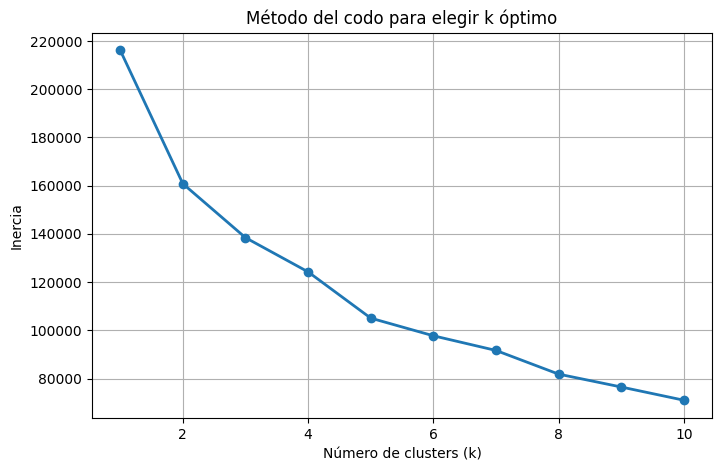

In [8]:
inercias = metodo_del_codo(df, columnas_variables=variables, max_clusters=10)


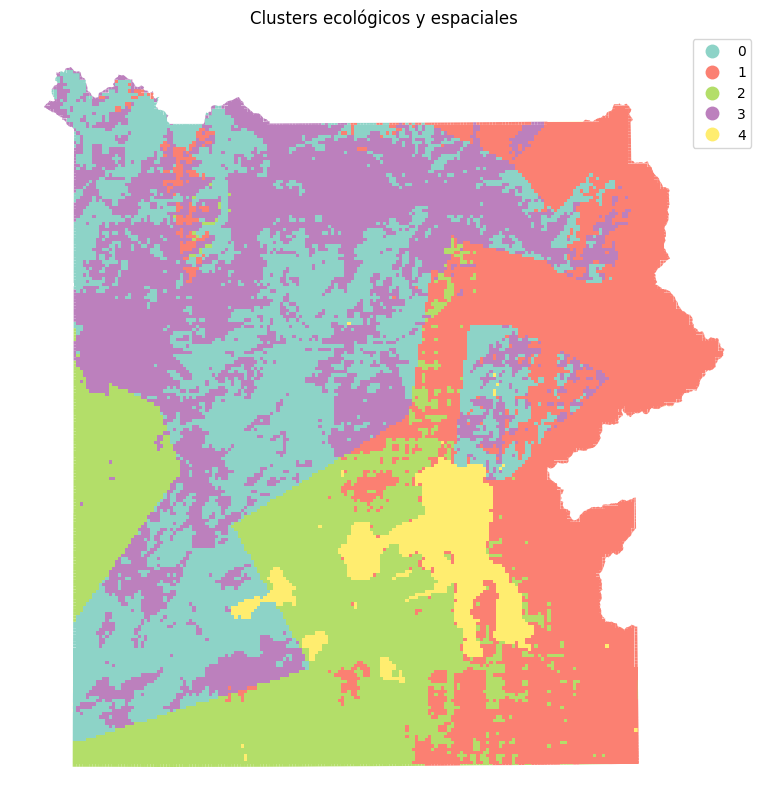

In [9]:
X = df[variables].copy()
# 4. Escalar todo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Aplicar KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Suponiendo que tu GeoDataFrame ya tiene la columna 'cluster'
fig, ax = plt.subplots(figsize=(10, 10))

df.plot(column='cluster', ax=ax, categorical=True, legend=True, cmap='Set3', markersize=2)

ax.set_title('Clusters ecológicos y espaciales')
ax.axis('off')
plt.show()


https://www.usgs.gov/media/images/nlcd-land-cover-classification-legend

/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/835093519.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=var, data=df, palette="pastel")
/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/835093519.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=var, data=df, palette="pastel")


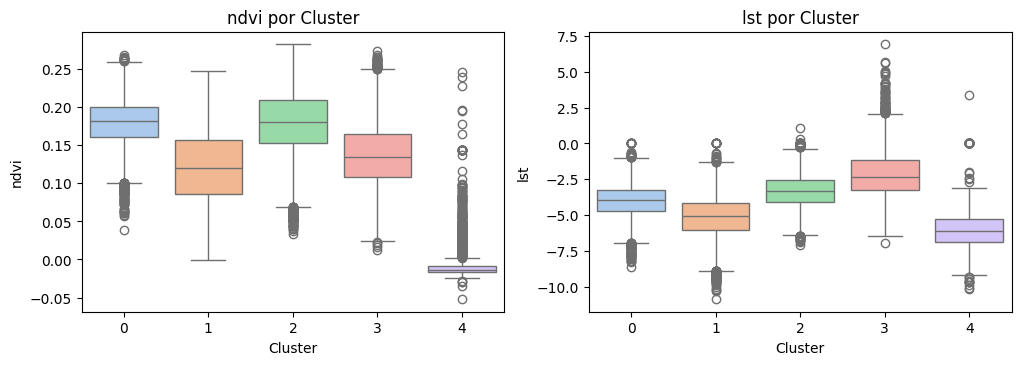

In [18]:
features_box = ['ndvi', 'lst']
n_cols = 2
n_rows = (len(features_box) + 1 + n_cols - 1) // n_cols  

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, var in enumerate(features_box):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x="cluster", y=var, data=df, palette="pastel")
    plt.title(f"{var} por Cluster")
    plt.xlabel("Cluster")
    plt.ylabel(var)


/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/3721890176.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="cluster", y="presencia_lobos", data=lobos_por_cluster, palette="muted")


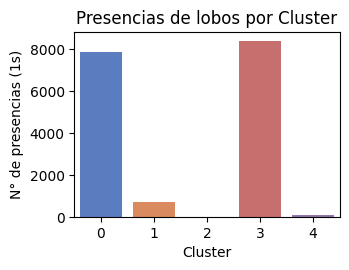

In [19]:
plt.subplot(n_rows, n_cols, len(features_box) + 1)

# Calcular número de presencias (1s) por cluster
lobos_por_cluster = df.groupby('cluster')['presencia_lobos'].sum().reset_index()
sns.barplot(x="cluster", y="presencia_lobos", data=lobos_por_cluster, palette="muted")

plt.title("Presencias de lobos por Cluster")
plt.xlabel("Cluster")
plt.ylabel("N° de presencias (1s)")

plt.tight_layout()
plt.show()

## Visualizar clases NLCD

/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/4036421521.py:20: RuntimeWarning: Mean of empty slice
  r_means.append(np.nanmean(r))
/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/4036421521.py:21: RuntimeWarning: Mean of empty slice
  g_means.append(np.nanmean(g))
/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/4036421521.py:22: RuntimeWarning: Mean of empty slice
  b_means.append(np.nanmean(b))
/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/4036421521.py:20: RuntimeWarning: Mean of empty slice
  r_means.append(np.nanmean(r))
/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/4036421521.py:21: RuntimeWarning: Mean of empty slice
  g_means.append(np.nanmean(g))
/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/4036421521.py:22: RuntimeWarning: Mean of empty slice
  b_means.append(np.nanmean(b))
/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_48751/4036421521.py:20: RuntimeWarn

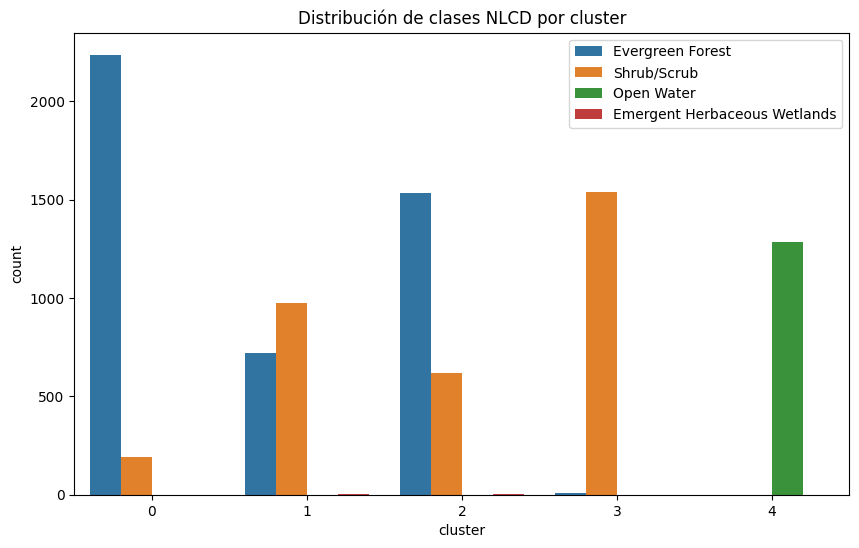

In [20]:
df2 = df.copy()
promedio_rgb_por_celda("datos/NLCD_reprojected_2021.tif", df2)
df2['mean_r'] = df2['mean_r'].fillna(df2['mean_r'].mean())
df2['mean_g'] = df2['mean_g'].fillna(df2['mean_g'].mean())
df2['mean_b'] = df2['mean_b'].fillna(df2['mean_b'].mean())
nlcd_labels = [
    "Open Water", "Developed, Open Space", "Developed, Low Intensity", 
    "Developed, Medium Intensity", "Developed, High Intensity",
    "Barren Land", "Deciduous Forest", "Evergreen Forest", 
    "Mixed Forest", "Shrub/Scrub", "Grassland/Herbaceous", 
    "Pasture/Hay", "Cultivated Crops", "Woody Wetlands", 
    "Emergent Herbaceous Wetlands"
]

nlcd_colors = [
    '#466b9f', '#d1def8', '#dec5c5', '#d99282', '#eb0000',
    '#ab0000', '#ba2dba', '#68ab5f', '#1c5f2c', '#b5ca8f',
    '#a2ff00', '#f0e442', '#006400', '#c8e6c9', '#9de0ad'
]
nlcd_dict = dict(zip(nlcd_colors, nlcd_labels))

def rgb_to_hex(r, g, b):
    return f"#{int(r):02x}{int(g):02x}{int(b):02x}"

# Mapear RGB a hex y luego a clase NLCD
df2['hex_color'] = df2.apply(lambda row: rgb_to_hex(row['mean_r'], row['mean_g'], row['mean_b']), axis=1)
df2['nlcd_class'] = df2['hex_color'].map(nlcd_dict)

# Obtener clase NLCD dominante por cluster
cluster_classes = (
    df2.groupby('cluster')['nlcd_class']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'nlcd_class': 'dominant_nlcd_class'})
)

df2 = df2.merge(cluster_classes, on='cluster', how='left')


plt.figure(figsize=(10,6))
sns.countplot(data=df2, x='cluster', hue='nlcd_class')
plt.title("Distribución de clases NLCD por cluster")
plt.legend(loc='upper right')
plt.show()

